In [203]:
import pandas as pd
import os
import numpy as np
import math
import pytaxonkit
import subprocess
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [204]:
!datasets download virus genome accession "AF538689.1"  --include protein --filename "test-data.zip"

New version of client (18.28.0) available at https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/LATEST/linux-amd64/datasets.
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 6.65MB/s
Downloading: test-data.zip    847B 

In [137]:
!datasets summary taxonomy taxon "Barley"

Error: The taxonomy name 'Barley' is not exact. Try using one of the suggested taxids:
Barley yellow dwarf virus (species, taxid: 12037, viruses)
Barley stripe mosaic virus (no-rank, taxid: 12327, viruses)
Barley yellow dwarf virus-PAV (no-rank, taxid: 2169986, viruses)
Barley dwarf virus (no-rank, taxid: 497862, viruses)
Barley yellow dwarf virus MAV (no-rank, taxid: 2169984, viruses)
Barley virus G (no-rank, taxid: 1825924, viruses)
Cytorhabdovirus hordei (no-rank, taxid: 1985699, Barley yellow striate mosaic virus)
Barley yellow dwarf virus-PAS (no-rank, taxid: 2169985, viruses)
Barley yellow mosaic virus (no-rank, taxid: 12465, viruses)
Barley mild mosaic virus (no-rank, taxid: 12466, viruses)

Use datasets summary taxonomy taxon <command> --help for detailed help about a command.



In [205]:
def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index()
    count_df.columns=[column_name, count_column_name]
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    return count_df

def print_histogram(df, col_name, n_bins):
    sns.histplot(df[col_name])
    print(f"min seq len = {min(df[col_name])}")
    print(f"max seq len = {max(df[col_name])}")
    plt.show()
    
    freq, bins = np.histogram(df[col_name], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

def filter_with_threshold_percentage(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}")
    if n is None:
        n = df.shape[0]
    print(f"n= {n}")
    count_df = column_stats(df, column_name, n=n)
    percent_column_name = column_name + "_percent"
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [206]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429.csv")
df = pd.read_csv(dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (15731, 90)


Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species',
       'Genome Status', 'Strain', 'Serovar', 'Biovar', 'Pathovar', 'MLST',
       'Segment', 'Subtype', 'H_type', 'N_type', 'H1 Clade Global',
       'H1 Clade US', 'H5 Clade', 'pH1N1-like', 'Lineage', 'Clade', 'Subclade',
       'Other Typing', 'Culture Collection', 'Type Strain', 'Reference',
       'Genome Quality', 'Completion Date', 'Publication', 'Authors',
       'BioProject Accession', 'BioSample Accession', 'Assembly Accession',
       'SRA Accession', 'GenBank Accessions', 'Sequencing Center',
       'Sequencing Status', 'Sequencing Platform', 'Sequencing Depth',
       'Assembly Method', 'Chromosome', 'Plasmids', 'Contigs', 'Size',
       'GC Content', 'Contig L50', 'Contig N50', 'TRNA', 'RRNA', 'Mat Peptide',
       'CDS', 'Coarse Consistency', 'Fine Consistency', 'Ch

In [207]:
df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Host Age,Host Health,Host Group,Lab Host,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified
0,1000373.10,Rosellinia necatrix quadrivirus 1 W1118,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T11:05:04.123Z,2025-12-06T11:05:04.123Z
1,1000373.40,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.037Z,2025-12-06T08:01:47.037Z
2,1000373.50,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.164Z,2025-12-06T08:01:47.164Z
3,1000411.30,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:04:18.329Z,2021-01-23T22:04:18.329Z
4,1000411.40,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:06:18.856Z,2021-01-23T22:06:18.856Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15726,999729.23,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:40:21.986Z,2022-03-12T21:40:21.986Z
15727,999729.24,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:34:20.054Z,2022-03-12T21:34:20.054Z
15728,999729.25,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:49:25.104Z,2022-03-12T21:49:25.104Z
15729,999729.35,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-05-01T01:51:20.496Z,2022-05-01T01:51:20.496Z


In [208]:
df["Host Group"].value_counts()

Nonhuman Mammal    1395
Bacteria            882
Plant               779
Insect              770
Human               610
Avian               371
Tick                298
Lab                  79
Fish                 71
Reptile              35
Sea Mammal           25
Crustaceans          20
Amphibian             2
Fungi                 1
Name: Host Group, dtype: int64

In [209]:
df["Host Name"].nunique()

3771

In [210]:
df[df["Host Name"].isna()][["Genome Name", "GenBank Accessions"]]

,Genome Name,GenBank Accessions
33,Ljungan virus M1146,AF538689
35,Bos taurus papillomavirus 7,DQ217793
45,Simian sapelovirus 1 2383,NC_004451
46,Simian sapelovirus 1 2383,AY064708
47,Porcine sapelovirus 1 V13,AF406813
...,...,...
15631,Plutella xylostella granulovirus K1,AF270937
15633,Pseudomonas phage phi15,FR823298
15634,Tanapox virus TPV-Kenya,EF420156
15672,Titi monkey adenovirus ECC-2011,HQ913600


In [211]:
print(df["Host Name"].nunique())
print(df["Host Common Name"].nunique())

3771
369


In [212]:
print(sum(df["Host Name"].isna()))
print(sum(df["Host Common Name"].isna()))
print(sum(df["Host Name"].isna() & ~df["Host Common Name"].isna() ))

4349
10393
34


In [213]:
df[df["Host Name"].isna() & ~df["Host Common Name"].isna()][["Genome ID", "GenBank Accessions", "Host Name", "Host Common Name"]]

,Genome ID,GenBank Accessions,Host Name,Host Common Name
125,1.024541e+04,NC_006998,NaN,Lab host
126,1.025430e+04,AY243312,NaN,Lab host
519,1.078429e+04,NC_001540,NaN,Lab host
520,1.078829e+04,NC_001539,NaN,Lab host
521,1.079439e+04,NC_001510,NaN,Lab host
522,1.079440e+04,J02275,NaN,Lab host
951,1.133292e+06,JN939331,NaN,Lab host
952,1.133294e+06,JN939332,NaN,Lab host
1189,1.168745e+06,JQ797329,NaN,Lab host
2082,1.327970e+06,KC821606,NaN,Lab host


In [214]:
sum(~df["Host Name"].isna())

11382

In [215]:
df = df[~df["Host Name"].isna()]
df.shape

(11382, 90)

In [216]:
pytaxonkit.name2taxid(["Salmo salar"])

,Name,TaxID,Rank
0,Salmo salar,8030,species


In [217]:
!datasets summary taxonomy taxon "Salmo salar"

New version of client (18.28.0) available at https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/LATEST/linux-amd64/datasets.
{"reports": [{"query":["Salmo salar"],"taxonomy":{"classification":{"class":{"id":186623,"name":"Actinopteri"},"domain":{"id":2759,"name":"Eukaryota"},"family":{"id":8015,"name":"Salmonidae"},"genus":{"id":8028,"name":"Salmo"},"kingdom":{"id":33208,"name":"Metazoa"},"order":{"id":8006,"name":"Salmoniformes"},"phylum":{"id":7711,"name":"Chordata"},"species":{"id":8030,"name":"Salmo salar"}},"counts":[{"count":16,"type":"COUNT_TYPE_ASSEMBLY"},{"count":86726,"type":"COUNT_TYPE_GENE"},{"count":12199,"type":"COUNT_TYPE_tRNA"},{"count":20676,"type":"COUNT_TYPE_rRNA"},{"count":978,"type":"COUNT_TYPE_snRNA"},{"count":880,"type":"COUNT_TYPE_snoRNA"},{"count":43178,"type":"COUNT_TYPE_PROTEIN_CODING"},{"count":4861,"type":"COUNT_TYPE_ncRNA"},{"count":38,"type":"COUNT_TYPE_OTHER"}],"curator_common_name":"Atlantic salmon","current_scientific_name":{"authority":"Linnaeus, 

In [218]:
VERTEBRATA_TAX_ID = 7742

def get_host_metadata(host_names):
    host_metadata = {}
    error_hosts = []
    n = len(host_names)
    for i, host_name in enumerate(host_names):
        print(f"({i}) {host_name}")
        try: 
            output = subprocess.run(["datasets", "summary", "taxonomy", "taxon", host_name], capture_output=True)
            #tax_json = json.loads(output.stdout)["reports"][0]["taxonomy"]["classification"]
            output_json = json.loads(output.stdout)
            reports = output_json["reports"]
            report_count = int(output_json["total_count"])
            for report in reports:
                tax_json = report["taxonomy"]
                classification_json = tax_json["classification"]
                metadata = {}
                if "species" in classification_json:
                    metadata["species_tax_name"] = classification_json["species"]["name"]
                    metadata["species_tax_id"] = classification_json["species"]["id"]
    
                if "genus" in classification_json:
                    metadata["genus_tax_name"] = classification_json["genus"]["name"]
                    metadata["genus_tax_id"] = classification_json["genus"]["id"]
    
                if "family" in tax_json:
                    metadata["family_tax_name"] = classification_json["family"]["name"]
                    metadata["family_tax_id"] = classification_json["family"]["id"]
    
                parents = tax_json["parents"]
                if VERTEBRATA_TAX_ID in parents:
                    metadata["is_vertebrate"] = True
                else:
                    metadata["is_vertebrate"] = False
                    
                host_metadata[host_name] = metadata
        except Exception as e:
            error_hosts.append(host_name)
            print(e)
    return host_metadata, error_hosts

In [219]:
df["host_name_cleaned"] = df["Host Name"].apply(lambda x: " ".join(x.split(" ")[:2]))

/tmp/ipykernel_2443422/3428461402.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["host_name_cleaned"] = df["Host Name"].apply(lambda x: " ".join(x.split(" ")[:2]))


In [220]:
df["Host Name"].nunique()

3771

In [221]:
df["Host Name"].value_counts()

Homo sapiens                           577
Mycobacterium smegmatis mc2 155        172
Escherichia coli                       131
Klebsiella pneumoniae                  118
Pseudomonas aeruginosa                  85
                                      ... 
Salmo salar l. (atlantic salmon)         1
Cicer arietinum voucher dar 76857        1
Cicer arietinum voucher brip 52877a      1
Cicer arietinum voucher brip 52878a      1
Digitaria didactyla willd                1
Name: Host Name, Length: 3771, dtype: int64

In [222]:
df["host_name_cleaned"].nunique()

2635

In [223]:
df["host_name_cleaned"].value_counts()

Homo sapiens               579
Escherichia coli           302
Mycobacterium smegmatis    183
Klebsiella pneumoniae      174
Pseudomonas aeruginosa     143
                          ... 
Feral pigeon                 1
Cercopithecus mitis          1
Datura inoxia                1
Ictalurus punctatus          1
Rhododendron maximum         1
Name: host_name_cleaned, Length: 2635, dtype: int64

In [224]:
hosts = df["host_name_cleaned"].unique()

In [22]:
#host_metadata, error_hosts = get_host_metadata(hosts)

(0) Rosellinia necatrix
(1) Rodent
Expecting value: line 1 column 1 (char 0)
(2) Sandfly
Expecting value: line 1 column 1 (char 0)
(3) Homo sapiens
(4) mosquito
Expecting value: line 1 column 1 (char 0)
(5) Chilli
Expecting value: line 1 column 1 (char 0)
(6) Scalopus aquaticus
(7) Vernonia cinerea
(8) Perca fluviatilis
(9) Limnodynastes ornatus
(10) Gallus gallus
(11) Drosophila ananassae
(12) Diptera
(13) Sida sp.
(14) Shigella flexneri
(15) Hardenbergia comptoniana
(16) Spissistilus festinus
(17) Lutzomyia sp.
(18) Staphylococcus aureus
(19) Ipomoea batatas
(20) Ipomoea purpurea
(21) Ipomoea indica
(22) Rhodococcus equi
(23) Trichomonas vaginalis
(24) Triticum aestivum
(25) Ixodes (Trichotoixodes)
Expecting value: line 1 column 1 (char 0)
(26) Uria sp.
Expecting value: line 1 column 1 (char 0)
(27) Musa sp.
(28) Euphorbia heterophylla
(29) cutthroat trout
(30) Thysanoplusia orichalcea
(31) raccoon
(32) Columba livia
(33) sheep
(34) Solanum lycopersicum
(35) Stenotrophomonas maltophi

In [230]:
host_metadata_df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_host_metadata.csv"), index_col=0)
host_metadata = host_metadata_df.to_dict("index")
host_metadata
#host_metadata_df = pd.DataFrame(host_metadata).transpose()
#host_metadata_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_host_metadata.csv"))

{'Rosellinia necatrix': {'species_tax_name': 'Rosellinia necatrix',
  'species_tax_id': 77044.0,
  'genus_tax_name': 'Rosellinia',
  'genus_tax_id': 77043.0,
  'is_vertebrate': False},
 'Homo sapiens': {'species_tax_name': 'Homo sapiens',
  'species_tax_id': 9606.0,
  'genus_tax_name': 'Homo',
  'genus_tax_id': 9605.0,
  'is_vertebrate': True},
 'Scalopus aquaticus': {'species_tax_name': 'Scalopus aquaticus',
  'species_tax_id': 71119.0,
  'genus_tax_name': 'Scalopus',
  'genus_tax_id': 71118.0,
  'is_vertebrate': True},
 'Vernonia cinerea': {'species_tax_name': 'Cyanthillium cinereum',
  'species_tax_id': 211151.0,
  'genus_tax_name': 'Cyanthillium',
  'genus_tax_id': 434644.0,
  'is_vertebrate': False},
 'Perca fluviatilis': {'species_tax_name': 'Perca fluviatilis',
  'species_tax_id': 8168.0,
  'genus_tax_name': 'Perca',
  'genus_tax_id': 8166.0,
  'is_vertebrate': True},
 'Limnodynastes ornatus': {'species_tax_name': 'Platyplectrum ornatum',
  'species_tax_id': 2741728.0,
  'genus_

In [231]:
len(host_metadata)

2193

In [233]:
df["virus_host_species_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_id") if x in host_metadata else None)

/tmp/ipykernel_2443422/3630995619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_id"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_id") if x in host_metadata else None)


In [234]:
df["virus_host_species_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_name") if x in host_metadata else None)

/tmp/ipykernel_2443422/3603374661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_name"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("species_tax_name") if x in host_metadata else None)


In [235]:
df["virus_host_is_vertebrate"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("is_vertebrate") if x in host_metadata else None)

/tmp/ipykernel_2443422/3631739729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_is_vertebrate"] = df["host_name_cleaned"].apply(lambda x: host_metadata.get(x).get("is_vertebrate") if x in host_metadata else None)


In [236]:
df 

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified,host_name_cleaned,virus_host_species_tax_id,virus_host_species_tax_name,virus_host_is_vertebrate
0,1000373.10,Rosellinia necatrix quadrivirus 1 W1118,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,2025-12-06T11:05:04.123Z,2025-12-06T11:05:04.123Z,Rosellinia necatrix,77044.0,Rosellinia necatrix,False
1,1000373.40,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.037Z,2025-12-06T08:01:47.037Z,Rosellinia necatrix,77044.0,Rosellinia necatrix,False
2,1000373.50,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.164Z,2025-12-06T08:01:47.164Z,Rosellinia necatrix,77044.0,Rosellinia necatrix,False
3,1000411.30,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T22:04:18.329Z,2021-01-23T22:04:18.329Z,Rodent,NaN,None,None
4,1000411.40,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T22:06:18.856Z,2021-01-23T22:06:18.856Z,Rodent,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15726,999729.23,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2022-03-12T21:40:21.986Z,2022-03-12T21:40:21.986Z,Anopheles meraukensis,59157.0,Anopheles meraukensis,False
15727,999729.24,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2022-03-12T21:34:20.054Z,2022-03-12T21:34:20.054Z,Anopheles meraukensis,59157.0,Anopheles meraukensis,False
15728,999729.25,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2022-03-12T21:49:25.104Z,2022-03-12T21:49:25.104Z,Anopheles meraukensis,59157.0,Anopheles meraukensis,False
15729,999729.35,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2022-05-01T01:51:20.496Z,2022-05-01T01:51:20.496Z,Anopheles meraukensis,59157.0,Anopheles meraukensis,False


In [237]:
df[df["virus_host_species_tax_id"].isna()]

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified,host_name_cleaned,virus_host_species_tax_id,virus_host_species_tax_name,virus_host_is_vertebrate
3,1000411.30,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T22:04:18.329Z,2021-01-23T22:04:18.329Z,Rodent,NaN,None,None
4,1000411.40,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T22:06:18.856Z,2021-01-23T22:06:18.856Z,Rodent,NaN,None,None
5,1000411.50,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T22:06:19.344Z,2021-01-23T22:06:19.344Z,Rodent,NaN,None,None
6,1000645.30,Ariquemes virus,NaN,1000645,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T21:53:37.675Z,2021-01-23T21:53:37.675Z,Sandfly,NaN,None,None
7,1000645.40,Ariquemes virus,NaN,1000645,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,NaN,NaN,2021-01-23T21:53:37.850Z,2021-01-23T21:53:37.850Z,Sandfly,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15533,93386.25,Columbid alphaherpesvirus 1 HLJ,NaN,93386,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,NaN,NaN,NaN,NaN,2021-01-10T14:33:59.387Z,2021-01-10T14:33:59.387Z,feral pigeons,NaN,None,None
15534,93386.47,Columbid alphaherpesvirus 1 HLJ,NaN,93386,10239;2731341;2731360;2731361;2731363;548681;3...,Viruses;Duplodnaviria;Heunggongvirae;Peploviri...,Viruses,Heunggongvirae,Peploviricota,Herviviricetes,...,NaN,NaN,NaN,NCBI Virus RefSeqs The NCBI RefSeq project lev...,2021-01-10T19:36:36.511Z,2021-01-10T19:36:36.511Z,feral pigeons,NaN,None,None
15535,935473.50,Rhynchosia yellow mosaic India virus Thiruvana...,NaN,935473,10239;2731342;2732092;2732416;2732424;2732539;...,Viruses;Monodnaviria;Shotokuvirae;Cressdnaviri...,Viruses,Shotokuvirae,Cressdnaviricota,Repensiviricetes,...,NaN,NaN,NaN,NaN,2025-12-16T15:07:07.341Z,2025-12-16T15:07:07.341Z,Rhynchosia,NaN,NaN,False
15536,935473.70,Rhynchosia yellow mosaic India virus Thiruvana...,NaN,935473,10239;2731342;2732092;2732416;2732424;2732539;...,Viruses;Monodnaviria;Shotokuvirae;Cressdnaviri...,Viruses,Shotokuvirae,Cressdnaviricota,Repensiviricetes,...,NaN,NaN,NaN,NaN,2025-12-16T15:07:11.283Z,2025-12-16T15:07:11.283Z,Rhynchosia,NaN,NaN,False


In [238]:
set(df["host_name_cleaned"].unique()) - set(host_metadata.keys())

{'1802)',
 'Abelmoscus esculentus',
 'Abelmoshus esculentus',
 'Abutilon sp.',
 'Acalypha sp.',
 'Adult cotesia',
 'Adult female',
 'Aedeomyia (ochler)',
 'Aeonium sp.',
 'Aeromonas hydrophila;Aeromonas',
 'African green',
 'African penguin',
 'Agapanthus sp.',
 'Aiptasia sp.',
 'Albelmoschus esculentus',
 'Alcea sp.',
 'Alpinia sp.',
 'Althea rosea',
 'Amblyomma (Theileriella)',
 'American white-tailed',
 'Anatid species',
 'Anthurium sp.',
 'Apple tree',
 'Arachis hypogea',
 'Arachis hypogeae',
 'Asgard group',
 'Ash gourd',
 'Ashy-headed sheldgoose',
 'Asian lion',
 'Asteraceae)',
 'Atcc 33303',
 'Bacilluls thuringiensis',
 'Bacillus cereus/thuringiensis',
 'Bacillus pseudalcaliphilus',
 'Bacillus sp.',
 'Bacillus thuringienses',
 'Bambusoideae sp.',
 'Banana',
 'Barley',
 'Bat',
 'Bat colony',
 'Bell pepper',
 'Bermeya goat',
 'Bhk-21',
 'Bing cherry',
 'Bird(acrocephalus schoenbaeus)',
 'Bird(andropadus virens)',
 'Bird(euplectes afra)',
 'Bird(ploceus melanocephalus)',
 'Bird(syl

In [239]:
df = df[~df["virus_host_species_tax_id"].isna()]

In [240]:
df.shape

(10056, 94)

In [241]:
df["virus_host_species_tax_id"] = df["virus_host_species_tax_id"].astype(int)

/tmp/ipykernel_2443422/3419116339.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["virus_host_species_tax_id"] = df["virus_host_species_tax_id"].astype(int)


In [242]:
df["virus_host_species_tax_id"].nunique()

1982

In [243]:
df["virus_host_is_vertebrate"].value_counts()

False    6891
True     3165
Name: virus_host_is_vertebrate, dtype: int64

In [245]:
df = df[df["virus_host_is_vertebrate"] == True]
df.shape

(3165, 94)

#### Remove records with virus_genus_tax_name == NULL

In [248]:
df = df[~df["Genus"].isna()]
df.shape

(2998, 94)

In [249]:
print(df["virus_host_species_tax_id"].nunique())
column_stats(df, "virus_host_species_tax_name")

548
Number of unique values = 548


,virus_host_species_tax_name,virus_host_species_tax_name_count,virus_host_species_tax_name_percent
0,Homo sapiens,575,19.179453
1,Gallus gallus,145,4.836558
2,Sus scrofa,84,2.801868
3,Bos taurus,63,2.101401
4,Equus caballus,42,1.400934
...,...,...,...
543,Lagothrix lagotricha,1,0.033356
544,Falco sparverius,1,0.033356
545,Oligoryzomys flavescens,1,0.033356
546,Oligoryzomys longicaudatus,1,0.033356


In [250]:
column_stats(df, "virus_host_species_tax_id")[:10]

Number of unique values = 548


,virus_host_species_tax_id,virus_host_species_tax_id_count,virus_host_species_tax_id_percent
0,9606,575,19.179453
1,9031,145,4.836558
2,9823,84,2.801868
3,9913,63,2.101401
4,9796,42,1.400934
5,10116,41,1.367578
6,9612,39,1.300867
7,8574,34,1.134089
8,10090,28,0.933956
9,9598,28,0.933956


In [251]:
column_stats(df, "Species")

Number of unique values = 1416


,Species,Species_count,Species_percent
0,Alphainfluenzavirus influenzae,45,1.501001
1,Orthoreovirus avis,40,1.334223
2,Orthoreovirus mammalis,25,0.833889
3,Mastadenovirus dominans,24,0.800534
4,Aquareovirus scophthalmi,22,0.733823
...,...,...,...
1410,Circovirus lepakko,1,0.033356
1411,Circovirus morcego,1,0.033356
1412,Cosavirus depakis,1,0.033356
1413,Cosavirus eaustrali,1,0.033356


In [252]:
column_stats(df, "Genus")

Number of unique values = 361


,Genus,Genus_count,Genus_percent
0,Orthoreovirus,183,6.104069
1,Mastadenovirus,106,3.535690
2,Alphapolyomavirus,101,3.368913
3,Rotavirus,94,3.135424
4,Phlebovirus,91,3.035357
...,...,...,...
356,Kopavirus,1,0.033356
357,Kappatorquevirus,1,0.033356
358,Epsilonpapillomavirus,1,0.033356
359,Paundivirus,1,0.033356


In [276]:
proteomes_proteins_dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins.csv")
proteomes_proteins_df = pd.read_csv(proteomes_proteins_dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {proteomes_proteins_df.shape}")
proteomes_proteins_df.columns

Dataset size: (512344, 4)


Index(['proteome_id', 'protein_id', 'sequence', 'protein'], dtype='object')

min seq len = 1
max seq len = 1306


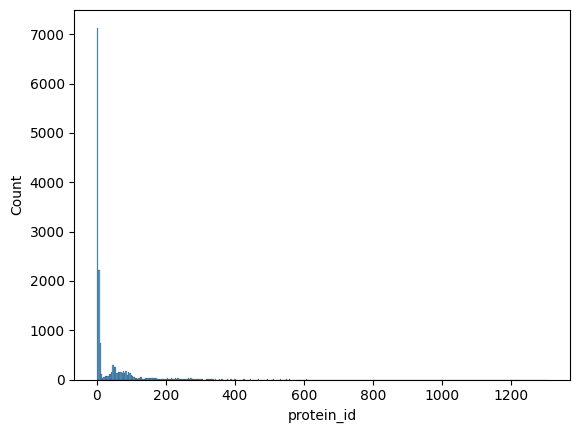

      start      end  count  percentage
0      1.00    14.05  10211   69.372919
1     14.05    27.10    188    1.277261
2     27.10    40.15    305    2.072152
3     40.15    53.20    749    5.088661
4     53.20    66.25    592    4.022012
..      ...      ...    ...         ...
95  1240.75  1253.80      0    0.000000
96  1253.80  1266.85      0    0.000000
97  1266.85  1279.90      0    0.000000
98  1279.90  1292.95      0    0.000000
99  1292.95  1306.00      1    0.006794

[100 rows x 4 columns]


In [277]:
print_histogram(pd.DataFrame(proteomes_proteins_df[["proteome_id", "protein_id"]].groupby("proteome_id").agg("count")).reset_index(), "protein_id", 100)

In [278]:
merged_df = pd.merge(df, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
merged_df.shape

(35865, 98)

min seq len = 1
max seq len = 274


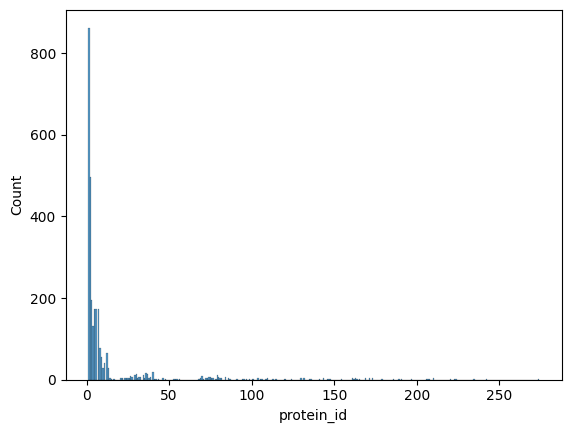

     start     end  count  percentage
0     1.00    3.73   1553   54.491228
1     3.73    6.46    480   16.842105
2     6.46    9.19    305   10.701754
3     9.19   11.92     68    2.385965
4    11.92   14.65     99    3.473684
..     ...     ...    ...         ...
95  260.35  263.08      0    0.000000
96  263.08  265.81      0    0.000000
97  265.81  268.54      0    0.000000
98  268.54  271.27      0    0.000000
99  271.27  274.00      2    0.070175

[100 rows x 4 columns]


In [279]:
print_histogram(pd.DataFrame(merged_df[["proteome_id", "protein_id"]].groupby("proteome_id").agg("count")).reset_index(), "protein_id", 100)

In [280]:
df_one_percent_prevelance = filter_with_threshold_percentage(df, "virus_host_species_tax_id", 1, n=df.shape[0])

Size of df = (2998, 94)
n= 2998
Number of unique values = 548
Size of filtered df = (1023, 94)
Number of unique values = 8


In [302]:
column_stats(df_one_percent_prevelance, "virus_host_species_tax_id", n=df.shape[0])

Number of unique values = 8


,virus_host_species_tax_id,virus_host_species_tax_id_count,virus_host_species_tax_id_percent
0,9606,575,19.179453
1,9031,145,4.836558
2,9823,84,2.801868
3,9913,63,2.101401
4,9796,42,1.400934
5,10116,41,1.367578
6,9612,39,1.300867
7,8574,34,1.134089


In [282]:
column_stats(df_one_percent_prevelance, "Species", n=df.shape[0])

Number of unique values = 412


,Species,Species_count,Species_percent
0,Alphainfluenzavirus influenzae,45,1.501001
1,Mastadenovirus dominans,24,0.800534
2,Rotavirus phigastroenteritidis,22,0.733823
3,Rotavirus deltagastroenteritidis,22,0.733823
4,Orbivirus orungoense,20,0.667111
...,...,...,...
407,Alphavirus rossriver,1,0.033356
408,Rubivirus rubellae,1,0.033356
409,Porcine astrovirus 4,1,0.033356
410,Aglavirus caranthi,1,0.033356


In [283]:
column_stats(df_one_percent_prevelance, "Genus", n=df.shape[0])

Number of unique values = 147


,Genus,Genus_count,Genus_percent
0,Rotavirus,70,2.334890
1,Gammapapillomavirus,57,1.901268
2,Phlebovirus,50,1.667779
3,Alphainfluenzavirus,45,1.501001
4,Orbivirus,41,1.367578
...,...,...,...
142,Erbovirus,1,0.033356
143,Sapelovirus,1,0.033356
144,Pipapillomavirus,1,0.033356
145,Avihepevirus,1,0.033356


In [284]:
merged_df_one_percent_prevelance = pd.merge(df_one_percent_prevelance, proteomes_proteins_df, left_on="GenBank Accessions", right_on="proteome_id")
print(merged_df_one_percent_prevelance.shape)
merged_df_one_percent_prevelance.columns

(9793, 98)


Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species',
       'Genome Status', 'Strain', 'Serovar', 'Biovar', 'Pathovar', 'MLST',
       'Segment', 'Subtype', 'H_type', 'N_type', 'H1 Clade Global',
       'H1 Clade US', 'H5 Clade', 'pH1N1-like', 'Lineage', 'Clade', 'Subclade',
       'Other Typing', 'Culture Collection', 'Type Strain', 'Reference',
       'Genome Quality', 'Completion Date', 'Publication', 'Authors',
       'BioProject Accession', 'BioSample Accession', 'Assembly Accession',
       'SRA Accession', 'GenBank Accessions', 'Sequencing Center',
       'Sequencing Status', 'Sequencing Platform', 'Sequencing Depth',
       'Assembly Method', 'Chromosome', 'Plasmids', 'Contigs', 'Size',
       'GC Content', 'Contig L50', 'Contig N50', 'TRNA', 'RRNA', 'Mat Peptide',
       'CDS', 'Coarse Consistency', 'Fine Consistency', 'Ch

In [285]:
merged_df_one_percent_prevelance["proteome_id"].nunique()

944

In [286]:
column_stats(merged_df_one_percent_prevelance, "Species", n=df.shape[0])

Number of unique values = 393


,Species,Species_count,Species_percent
0,Asfivirus haemorrhagiae,1446,48.232155
1,Mastadenovirus dominans,911,30.386925
2,Orthopoxvirus akhmetapox,440,14.676451
3,Aviadenovirus hepatitidis,231,7.705137
4,Mardivirus gallidalpha3,200,6.671114
...,...,...,...
388,Orthohantavirus sinnombreense,1,0.033356
389,Pestivirus ratti,1,0.033356
390,Protoambidensovirus incertum3,1,0.033356
391,Porcine teschovirus 15,1,0.033356


In [287]:
column_stats(merged_df_one_percent_prevelance, "Genus", n=df.shape[0])

Number of unique values = 143


,Genus,Genus_count,Genus_percent
0,Asfivirus,1446,48.232155
1,Mastadenovirus,1410,47.031354
2,Varicellovirus,831,27.718479
3,Orthopoxvirus,619,20.647098
4,Aviadenovirus,519,17.311541
...,...,...,...
138,Inpeasmacovirus,2,0.066711
139,Nauglamirvirus,2,0.066711
140,Parabovirus,1,0.033356
141,Protoambidensovirus,1,0.033356


In [288]:
merged_df_one_percent_prevelance["protein"] = merged_df_one_percent_prevelance["protein"].apply(lambda x: str(x).replace(" ", "-").replace(",", "-"))
merged_df_one_percent_prevelance["protein_id_name"] = merged_df_one_percent_prevelance["protein_id"] + "_" + merged_df_one_percent_prevelance["protein"]
merged_df_one_percent_prevelance

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Date Modified,host_name_cleaned,virus_host_species_tax_id,virus_host_species_tax_name,virus_host_is_vertebrate,proteome_id,protein_id,sequence,protein,protein_id_name
0,1000646.3,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,2021-01-23T21:53:40.170Z,Homo sapiens,9606,Homo sapiens,True,HM119410,AEA30058.1,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,L-protein,AEA30058.1_L-protein
1,1000646.4,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,2021-01-23T21:53:40.712Z,Homo sapiens,9606,Homo sapiens,True,HM119411,AEA30046.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,AEA30046.1_polyprotein
2,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,2021-01-23T21:53:40.599Z,Homo sapiens,9606,Homo sapiens,True,HM119412,AEA30072.1,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,nonstructural-protein,AEA30072.1_nonstructural-protein
3,1000646.5,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,2021-01-23T21:53:40.599Z,Homo sapiens,9606,Homo sapiens,True,HM119412,AEA30073.1,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,nucleocapsid,AEA30073.1_nucleocapsid
4,1000646.6,Echarate virus,NaN,1000646,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,2021-10-12T17:12:45.871Z,Homo sapiens,9606,Homo sapiens,True,NC_055341,YP_010086120.1,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,polyprotein,YP_010086120.1_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,994995.6,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,2021-01-24T04:38:40.241Z,chicken,9031,Gallus gallus,True,JQ920006,AFL91895.1,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,VP4,AFL91895.1_VP4
9789,994995.7,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,2021-01-24T04:38:41.277Z,chicken,9031,Gallus gallus,True,JQ920007,AFL91896.1,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,VP7,AFL91896.1_VP7
9790,994995.8,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,2021-01-24T04:38:41.047Z,chicken,9031,Gallus gallus,True,JQ920008,AFL91897.1,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,NSP1-1,AFL91897.1_NSP1-1
9791,994995.8,Rotavirus G chicken/03V0567/DEU/2003,NaN,994995,10239;2559587;2732396;2732405;2732459;2788829;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Resentoviricetes,...,2021-01-24T04:38:41.047Z,chicken,9031,Gallus gallus,True,JQ920008,AFL91898.1,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,NSP1-2,AFL91898.1_NSP1-2


In [289]:
merged_df_one_percent_prevelance["protein_id_name"]

0                   AEA30058.1_L-protein
1                 AEA30046.1_polyprotein
2       AEA30072.1_nonstructural-protein
3                AEA30073.1_nucleocapsid
4             YP_010086120.1_polyprotein
                      ...               
9788                      AFL91895.1_VP4
9789                      AFL91896.1_VP7
9790                   AFL91897.1_NSP1-1
9791                   AFL91898.1_NSP1-2
9792                     AFL91899.1_NSP2
Name: protein_id_name, Length: 9793, dtype: object

In [290]:
clean_df = merged_df_one_percent_prevelance[["proteome_id", "protein_id", "protein", "protein_id_name", "virus_host_species_tax_id", "virus_host_species_tax_name", "Genus", "Species", "sequence"]].rename(columns={"Genus": "virus_genus_tax_name", "Species": "virus_species_tax_name"})
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...
...,...,...,...,...,...,...,...,...,...
9788,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...
9789,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...
9790,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...
9791,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...


#### Remove nucleotide sequences (noisy data). Sometimes the NCBI tool returns nucleotide sequences (reason unknown).

In [291]:
clean_df["is_nucleotide"] = clean_df["sequence"].apply(lambda x: sorted(set(x)) == ["A", "C", "G", "T"])

In [292]:
clean_df["is_nucleotide"].value_counts()

False    9655
True      138
Name: is_nucleotide, dtype: int64

In [293]:
clean_df = clean_df[clean_df["is_nucleotide"] == False]
print(clean_df["is_nucleotide"].value_counts())
clean_df.shape

False    9655
Name: is_nucleotide, dtype: int64


(9655, 10)

In [294]:
print(clean_df["proteome_id"].nunique())
clean_df["virus_species_tax_name"].nunique()

935


390

#### Drop all duplicated 'protein_id_names'

In [295]:
clean_df = clean_df.drop_duplicates(subset="protein_id_name", keep=False)
clean_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False
...,...,...,...,...,...,...,...,...,...,...
9788,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,False
9789,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,False
9790,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,False
9791,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,False


In [299]:
clean_df["proteome_id"].nunique()

935

In [300]:
clean_df.to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv"), index=False)

In [153]:
clean_df[clean_df["protein_id"] == "ACO92353.1"]

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide
7052,FJ463615,ACO92353.1,leader-peptide,ACO92353.1_leader-peptide,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,MCFTPSLWFKNCHSFSKPSGLGFPTLLTDNMACKHGYPFLCPLCTA...,False
7053,FJ463615,ACO92353.1,polyprotein,ACO92353.1_polyprotein,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,MCFTPSLWFKNCHSFSKPSGLGFPTLLTDNMACKHGYPFLCPLCTA...,False
7054,FJ463615,ACO92353.1,capsid-protein-VP4,ACO92353.1_capsid-protein-VP4,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,GNSNSSDKNNSQSSGNEGVIINNYYSNQYQNSIDLSANANGVGKEN...,False
7055,FJ463615,ACO92353.1,protein-2B,ACO92353.1_protein-2B,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,GGVLTKSQAPMSGLQSMLLRAIGIEADCTEFTRAVNLITDLCNTWE...,False
7056,FJ463615,ACO92353.1,protein-2C,ACO92353.1_protein-2C,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,SPIREANDNFNLAKNIEWAIKTIKRIVEWITSWFKQEETSPQAKLD...,False
7057,FJ463615,ACO92353.1,protein-3A,ACO92353.1_protein-3A,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,SPGNDMDYVLTCLRQTNAALQDQIDELQEAFNQAQERQNFLSDWLK...,False
7058,FJ463615,ACO92353.1,protein-3B,ACO92353.1_protein-3B,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,AAYSGGKKGEKQTLQVLDVQ,False
7059,FJ463615,ACO92353.1,protein-3C,ACO92353.1_protein-3C,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,GGGKIVAQAGNPVMDYEVNIAKNMVTPITFIYADKAQVTQSCLLIK...,False
7060,FJ463615,ACO92353.1,capsid-protein-VP2,ACO92353.1_capsid-protein-VP2,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,DQDTEEMTNLSDRVASDTAGNTATNTQSTVGRLFGYASRHRGKHPA...,False
7061,FJ463615,ACO92353.1,capsid-protein-VP3,ACO92353.1_capsid-protein-VP3,9606,Homo sapiens,Cardiovirus,Cardiovirus saffoldi,SPFPGTIREHAGTFYSTTPDTTVPVYGKTISTPANYMCGEFTDLLS...,False


In [330]:
!datasets download virus genome accession "AB003289.1"  --include protein --filename "test-data.zip"

Error: invalid or unsupported assembly accession: AB003289.1

Use datasets download genome accession <command> --help for detailed help about a command.



In [334]:
!datasets summary virus genome accession "AB003289.1" annotation

New version of client (18.26.0) available at https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/LATEST/linux-amd64/datasets.
{"reports": [{"accession":"AB003289.1","completeness":"PARTIAL","is_annotated":true,"isolate":{"name":"CG01BD","source":"blood"},"length":8953,"nucleotide":{"sequence_hash":"D573863E"},"protein_count":1,"release_date":"1997-09-30T00:00:00Z","source_database":"GenBank","submitter":{"affiliation":"Shunji Mishiro, Toshiba General Hospital, Dept. Medical Sciences; 6-3-22 Higashi Oh-i, Shinagawa-ku, Tokyo 140-8522","country":"Japan","names":["Takahashi,K.","Hijikata,M.","Aoyama,K.","Hoshino,H.","Hino,K.","Mishiro,S."]},"update_date":"2007-11-13T00:00:00Z","virus":{"lineage":[{"name":"Viruses","tax_id":10239},{"name":"Riboviria","tax_id":2559587},{"name":"Orthornavirae","tax_id":2732396},{"name":"Kitrinoviricota","tax_id":2732406},{"name":"Flasuviricetes","tax_id":2732462},{"name":"Amarillovirales","tax_id":2732545},{"name":"Flaviviridae","tax_id":11050},{"name":"P

In [154]:
clean_df["sequence_length"] = clean_df["sequence"].apply(lambda x: len(x))

min seq len = 8
max seq len = 7141


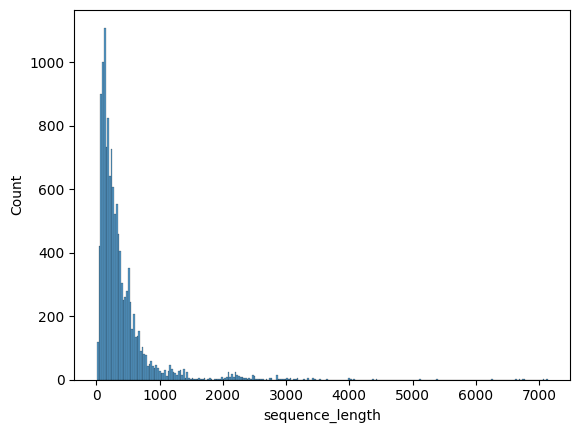

    start     end  count  percentage
0     8.0   721.3  11627   90.041044
1   721.3  1434.6    933    7.225277
2  1434.6  2147.9    133    1.029970
3  2147.9  2861.2    150    1.161620
4  2861.2  3574.5     46    0.356230
5  3574.5  4287.8     11    0.085185
6  4287.8  5001.1      2    0.015488
7  5001.1  5714.4      2    0.015488
8  5714.4  6427.7      1    0.007744
9  6427.7  7141.0      8    0.061953


In [156]:
print_histogram(clean_df, "sequence_length", 10)